# Open Policy Finder Green Paths

Looks up all of the _Closed_ articles to see if free green paths exist.

Rearrange this so you can load the pickles directly instea of API calls etc.

In [1]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import requests


In [23]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 600)
requests.packages.urllib3.disable_warnings()
colors = sns.color_palette('inferno_r')
color = sns.color_palette('inferno_r')[0]
WORKS_PICKLE = "2026_API_GRAB.pkl"
PF_PICKLE = "2026_PF_RAW.pkl"
CLOSED_WORKS_ANALYZED_PICKLE = "2026_CLOSED_ANALYZED.pkl" 
pf_key = "" #blanked out for GH purposes

In [3]:
#No full Python API for OPF, so just a light wrapper to make the code easier to read.
def pf_fetch(pf_key,identifier):
    '''Returns JSON from Policy Finder for whatever kind of identifier it is given.'''
    paip_params = {
        "item-type" : "publication",
        "format" : "Json",
        "identifier" : identifier,
    }
    
    paip_headers = {
            "x-api-key" : pf_key,
    }

    api_blob = requests.get("https://api.openpolicyfinder.jisc.ac.uk/retrieve_by_id",params=paip_params, headers=paip_headers).json()
    return api_blob

In [18]:
with open(WORKS_PICKLE, 'rb') as file:
    works = pickle.load(file)

w_df = pd.DataFrame(works)

i_del = []
for i,r in w_df.iterrows():
    if r['open_access']['is_oa'] == True:
        i_del.append(i)

w_df.drop(index=i_del, inplace= True)
w_df.reset_index(inplace=True)

In [19]:
#Add a column of issn based on contents of 'locations' -> 'source' -> 'issn'
#Assuming at this point in the game everything has an ISSN
issn_list = []
for i, r in w_df.iterrows():
    issn_list.append(r['locations'][0]['source']['issn'][0])
w_df['issn'] = issn_list

## Open Policy Finder

Will use issn to retrieve relevant OPF info. saves ID of policy as column 

In [22]:
#whip through all pf_requests and cache them...
#no caching possible as I can't get an ID for a policy until I give an ISSN
pf_list = []
pf_id = []

for i, r in w_df.iterrows():

    if(i % 50) == 0:
        print(i)
    
    pf_info = pf_fetch(pf_key,r['issn'])
    #pprint(pf_info)
    try:
        pf_id.append(pf_info['items'][0]['publisher_policy'][0]['id'])
        pf_list.append(pf_info)
    except:
        pf_list.append(np.nan)
        pf_id.append(np.nan)
        print("Policy not found")

w_df['OPF_id'] = pf_id
w_df['OPF_info'] = pf_list


0
Policy not found
Policy not found
Policy not found
Policy not found
50
Policy not found
Policy not found
100
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
150
Policy not found
Policy not found
Policy not found
Policy not found
200
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
250
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
Policy not found
300


In [29]:
#How many closed articles have no policy?
w_df['OPF_id'].isna().sum()

np.int64(37)

In [34]:
#How many duplicates do we have?
#w_df['OPF_id'].value_counts()

## Policy Text

How do I find out if a policy has a free green path?

In [50]:
green_status = []
for i,r in w_df.iterrows():
    if pd.notna(r['OPF_id']):
        if r['OPF_info']['items'][0]['publisher_policy'][0]['permitted_oa'][0]['additional_oa_fee'] == "yes":
            green_status.append(True)
        else:
            green_status.append(False)

    else:
        green_status.append(np.nan)
    

In [52]:
w_df['free_green'] = green_status

In [53]:
w_df['free_green'].value_counts()

free_green
False    180
True      85
Name: count, dtype: int64

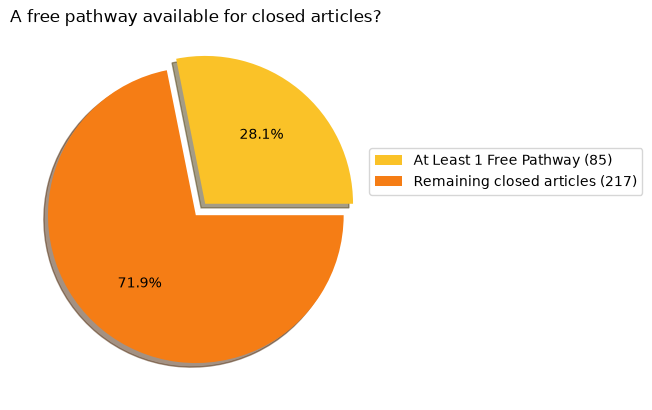

In [58]:
#at least one free pathway for closed articles
closed_articles = len(w_df)

least_one_free_pathway = len(w_df[w_df['free_green']==True])
total_remaining_closed = closed_articles - least_one_free_pathway


legend = ["At Least 1 Free Pathway ("+str(least_one_free_pathway)+")","Remaining closed articles ("+str(total_remaining_closed)+")"]
explode = (0.1, 0.0)
plt.pie([least_one_free_pathway,total_remaining_closed],autopct="%1.1f%%",explode=explode,shadow=True,startangle=0,colors=colors)
plt.legend(legend,bbox_to_anchor=(0.95,0.7))
plt.title("A free pathway available for closed articles?")

figname = "One_Free_Pathway.png"
plt.savefig(figname, bbox_inches='tight')
plt.show()


## Corresponding Author

## Marker

In [176]:
# TESTING CELL
# https://doi.org/10.1016/j.pacfin.2025.102866
# - - Science Direct
# Pacific-Basin Finance Journal
# very much 'closed'
# ISSN 1879-0585
# pf_info['items'][0]['id'] = 17114
# need another Elsevier journal to test against: https://doi.org/10.1016/j.indmarman.2025.08.003

interesting_doi = "https://doi.org/10.1016/j.pacfin.2025.102866"
#interesting_doi = "https://doi.org/10.1016/j.indmarman.2025.08.003"

issn = w_df[w_df["doi"] == interesting_doi]['issn']
pf_info = pf_fetch(pf_key,issn)
issn = w_df[w_df["doi"] == interesting_doi]

## Write out finals as pickles

In [26]:
#Pickles of our data

with open(CLOSED_WORKS_ANALYZED_PICKLE, "wb") as file:
    pickle.dump(w_df, file)


with open(PF_PICKLE, "wb") as file:
    pickle.dump(pf_list, file)